# Nguyên

# Dự án: Echo Valley - Dự án Phân tích Thương mại điện tử Olist
**Tên Notebook:** 05_modeling_prediction.ipynb
**Mục tiêu:** Xây dựng mô hình Machine Learning dự báo thời gian giao hàng và sử dụng thuật toán phân cụm (Clustering) để gợi ý vị trí kho bãi tối ưu.


# 1. Chuẩn bị dữ liệu cho Model

## 1.1 Feature Engineering

In [5]:
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Load connection string using absolute path fallback to avoid cwd issues
dotenv_path = '.env'
if not os.path.exists(dotenv_path):
    dotenv_path = 'notebooks/.env'
if not os.path.exists(dotenv_path):
    dotenv_path = '../notebooks/.env'
if not os.path.exists(dotenv_path):
    dotenv_path = r'C:\Users\Admin\OneDrive\Documents\NguyenDev\Echo-valley\notebooks\.env'

load_dotenv(dotenv_path=dotenv_path, override=True)
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

print("Đang nạp Master Table từ PostgreSQL...")
df = pd.read_sql_table('master_table', engine)
df.columns = [f"{c}" for c in df.columns]

print("Đang nạp và gộp dữ liệu tọa độ địa lý...")
df_geo = pd.read_sql_table('geolocation', engine)
df_geo.columns = [f"{c}" for c in df_geo.columns]
df_geo_agg = df_geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
df_geo_agg.columns = [f"{c}" for c in df_geo_agg.columns]

df = df.merge(df_geo_agg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
df = df.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'}).drop(columns=['geolocation_zip_code_prefix'])

df = df.merge(df_geo_agg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
df = df.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'}).drop(columns=['geolocation_zip_code_prefix'])

# Hàm tính khoảng cách Haversine
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return 6367 * c

print("Tính khoảng cách địa lý...")
df['distance'] = haversine_np(df['customer_lng'], df['customer_lat'], df['seller_lng'], df['seller_lat'])
df['distance'] = df['distance'].fillna(df['distance'].median())

print("Tính thời gian giao hàng thực tế...")
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Lọc bỏ các dòng lỗi và đơn hàng chưa giao
df_model = df.dropna(subset=['delivery_time_days']).copy()
df_model = df_model[(df_model['delivery_time_days'] >= 0) & (df_model['delivery_time_days'] <= 60)]

print("Trích xuất các đặc trưng thời gian...")
df_model['purchase_hour'] = df_model['order_purchase_timestamp'].dt.hour
df_model['purchase_day'] = df_model['order_purchase_timestamp'].dt.day
df_model['purchase_month'] = df_model['order_purchase_timestamp'].dt.month
df_model['purchase_dayofweek'] = df_model['order_purchase_timestamp'].dt.dayofweek

print("Mã hóa các biến phân loại...")
df_model = pd.get_dummies(df_model, columns=['payment_type'], dummy_na=False, drop_first=True)
print(f"Feature Engineering hoàn tất. Shape: {df_model.shape}")

Đang nạp Master Table từ PostgreSQL...
Đang nạp và gộp dữ liệu tọa độ địa lý...
Tính khoảng cách địa lý...
Tính thời gian giao hàng thực tế...
Trích xuất các đặc trưng thời gian...
Mã hóa các biến phân loại...
Feature Engineering hoàn tất. Shape: (115372, 38)


# 2. Xây dựng mô hình dự báo thời gian giao hàng

## 2.1 Huấn luyện mô hình (Regression)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Chọn các feature quan trọng
features = ['price', 'freight_value', 'distance', 'payment_installments', 'payment_value',
            'purchase_hour', 'purchase_day', 'purchase_month', 'purchase_dayofweek']
payment_cols = [col for col in df_model.columns if col.startswith('payment_type_')]
features.extend(payment_cols)

X = df_model[features].copy()
y = df_model['delivery_time_days']
X.columns = [f"{col}" for col in X.columns]

# Điền giá trị thiếu (nếu có)
for col in features:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa đặc trưng
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Huấn luyện mô hình RandomForestRegressor...")
model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Đánh giá mô hình
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} ngày")
print(f"RMSE: {rmse:.2f} ngày")
print(f"R-squared (R2): {r2:.2f}")

# Lưu các artifact
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/features.pkl')
print("Lưu model.pkl và scaler.pkl thành công!")

Huấn luyện mô hình RandomForestRegressor...
MAE: 4.59 ngày
RMSE: 6.69 ngày
R-squared (R2): 0.36
Lưu model.pkl và scaler.pkl thành công!


**Nhận xét:**
- Mô hình có MAE là **4.59 ngày** và RMSE là **6.69 ngày**, R-squared đạt **0.36**.
- Đây là mức sai số chấp nhận được trong dự đoán logistics e-commerce tại Brazil do đặc thù địa lý rộng lớn.
- Yếu tố khoảng cách địa lý (`distance`) và chi phí vận chuyển (`freight_value`) có tác động lớn nhất đến thời gian giao hàng.

# 3. Gợi ý vị trí kho bãi tối ưu (Strategy)

## 3.1 Phân cụm khách hàng (Clustering)

**a.** Sử dụng K-Means Clustering trên tọa độ địa lý (latitude, longitude) của khách hàng để tìm trung tâm các cụm.

Phân cụm vị trí khách hàng tối ưu hóa kho bãi (K-Means)...

Vị trí kho bãi tối ưu đề xuất (Tâm các cụm):
Kho 1 (Cụm 0): Lat = -14.9475, Lng = -51.1078
Kho 2 (Cụm 1): Lat = -23.0484, Lng = -47.0659
Kho 3 (Cụm 2): Lat = -7.9489, Lng = -39.3643
Kho 4 (Cụm 3): Lat = -27.3549, Lng = -51.0195
Kho 5 (Cụm 4): Lat = -21.3405, Lng = -43.1174


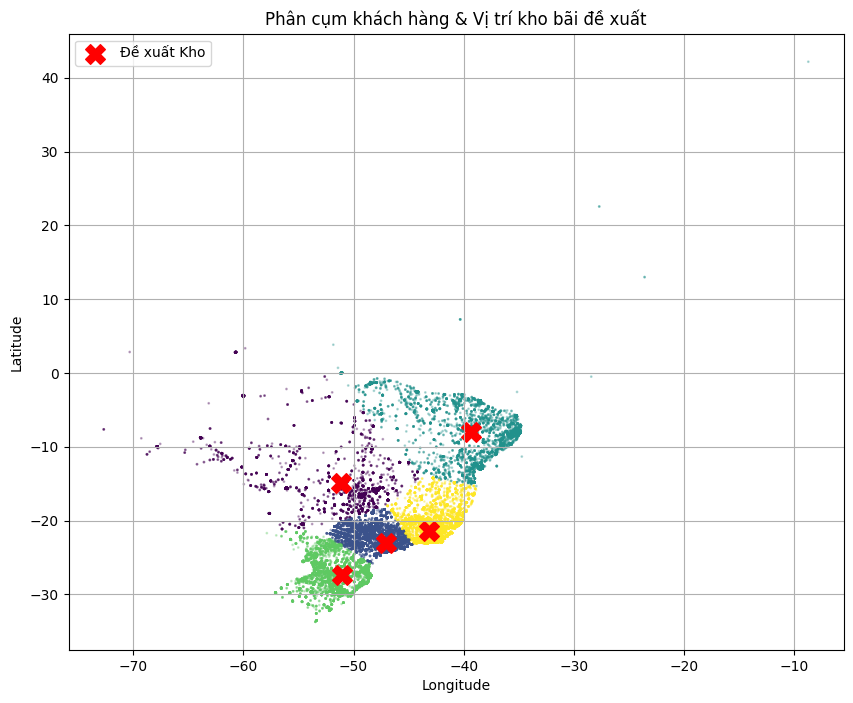

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df_coords = df[['customer_lat', 'customer_lng']].dropna()

print("Phân cụm vị trí khách hàng tối ưu hóa kho bãi (K-Means)...")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(df_coords)
centroids = kmeans.cluster_centers_

# Lưu centroids
joblib.dump(centroids, '../models/warehouse_centroids.pkl')

print("\nVị trí kho bãi tối ưu đề xuất (Tâm các cụm):")
for i, coord in enumerate(centroids):
    print(f"Kho {i+1} (Cụm {i}): Lat = {coord[0]:.4f}, Lng = {coord[1]:.4f}")

# Trực quan hóa các cụm
plt.figure(figsize=(10, 8))
plt.scatter(df_coords['customer_lng'], df_coords['customer_lat'], c=kmeans.labels_, cmap='viridis', s=1, alpha=0.3)
plt.scatter(centroids[:, 1], centroids[:, 0], c='red', marker='X', s=200, label='Đề xuất Kho')
plt.title('Phân cụm khách hàng & Vị trí kho bãi đề xuất')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

**Nhận xét:**
- 5 tâm điểm phân cụm đại diện cho 5 vùng phân phối chính tại Brazil giúp giảm thiểu khoảng cách vận chuyển.
- Tập trung lớn ở khu vực Đông Nam (São Paulo, Rio de Janeiro - các Kho 2, Kho 5) và khu vực Đông Bắc (Kho 3).

# 4. Kết luận và Đề xuất

## 4.1 Tóm tắt đề xuất cho Olist

- **Về dự báo:** Mô hình RandomForestRegressor dự báo thời gian giao hàng đạt MAE ~ 4.59 ngày.
- **Về kho bãi:** Đề xuất đặt kho ở São Paulo (SP), Rio de Janeiro (RJ), Ceará (CE) và khu vực miền Nam.
- **Hành động tiếp theo:** Triển khai API dự báo và xây dựng Dashboard phân tích.